In [80]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
data_path = os.path.join("data", 'HR_data_2.csv')
df = pd.read_csv(data_path)

In [82]:
len(df)

312

In [83]:
df.columns

Index(['Unnamed: 0', 'HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min',
       'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew',
       'HR_TD_Slope_min', 'HR_TD_Slope_max', 'HR_TD_Slope_mean', 'HR_TD_Slope',
       'TEMP_TD_Mean', 'TEMP_TD_Median', 'TEMP_TD_std', 'TEMP_TD_Min',
       'TEMP_TD_Max', 'TEMP_TD_AUC', 'TEMP_TD_Kurtosis', 'TEMP_TD_Skew',
       'TEMP_TD_Slope_min', 'TEMP_TD_Slope_max', 'TEMP_TD_Slope_mean',
       'TEMP_TD_Slope', 'EDA_TD_P_Mean', 'EDA_TD_P_Median', 'EDA_TD_P_std',
       'EDA_TD_P_Min', 'EDA_TD_P_Max', 'EDA_TD_P_AUC', 'EDA_TD_P_Kurtosis',
       'EDA_TD_P_Skew', 'EDA_TD_P_Slope_min', 'EDA_TD_P_Slope_max',
       'EDA_TD_P_Slope_mean', 'EDA_TD_P_Slope', 'EDA_TD_T_Mean',
       'EDA_TD_T_Median', 'EDA_TD_T_std', 'EDA_TD_T_Min', 'EDA_TD_T_Max',
       'EDA_TD_T_AUC', 'EDA_TD_T_Kurtosis', 'EDA_TD_T_Skew',
       'EDA_TD_T_Slope_min', 'EDA_TD_T_Slope_max', 'EDA_TD_T_Slope_mean',
       'EDA_TD_T_Slope', 'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_R

In [ ]:
# print(df.dtypes)
# print(df.dtypes.unique())
# string_columns = df.select_dtypes(include=['str']).columns
# print(string_columns)

# int_columns = df.select_dtypes(include=['int']).columns
# print(int_columns)

# remove columns
df = df.drop(columns=["Unnamed: 0", "Round", "Puzzler", "original_ID", "raw_data_path", "Team_ID"])

quastinare_columns = ["Frustrated","upset","hostile", "alert", "ashamed", "inspired", "nervous", "attentive", "afraid", "active", "determined"]
data_columns = [col for col in df.columns if col not in quastinare_columns + ["Phase"] + ["Individual"]]


In [ ]:
print(df[data_columns].isna().sum().sort_values(ascending=False)[:5])

EDA_TD_P_RT     1
EDA_TD_P_ReT    1
HR_TD_Mean      0
HR_TD_Min       0
HR_TD_Max       0
dtype: int64


In [ ]:
df = df.dropna(subset=data_columns)

In [87]:
df["Phase"].unique()

<StringArray>
['phase3', 'phase2', 'phase1']
Length: 3, dtype: str

In [ ]:
train_df = df[df["Phase"] != "phase2"]
test_df = df[df["Phase"] == "phase2"]

In [ ]:
scaler = StandardScaler()
train_df_scaled = scaler.fit_transform(train_df[data_columns])
test_df_scaled = scaler.transform(test_df[data_columns])

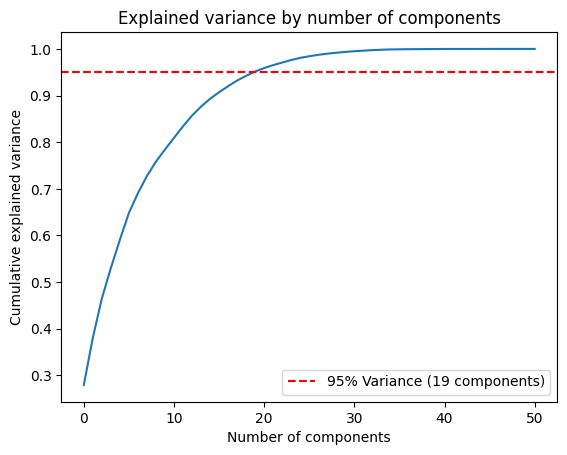

In [90]:
# make explained variance pca plot and select number of components that explain 95% of the variance
pca = PCA()
pca.fit(train_df_scaled)
explained_variance = pca.explained_variance_ratio_

# Find the number of components that explain 95% of the variance
n_components_95 = (explained_variance.cumsum() <= 0.95).sum()

plt.plot(explained_variance.cumsum())
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained variance by number of components")
plt.axhline(y=0.95, color='r', linestyle='--', label=f'95% Variance ({n_components_95} components)')
plt.legend()
plt.show()

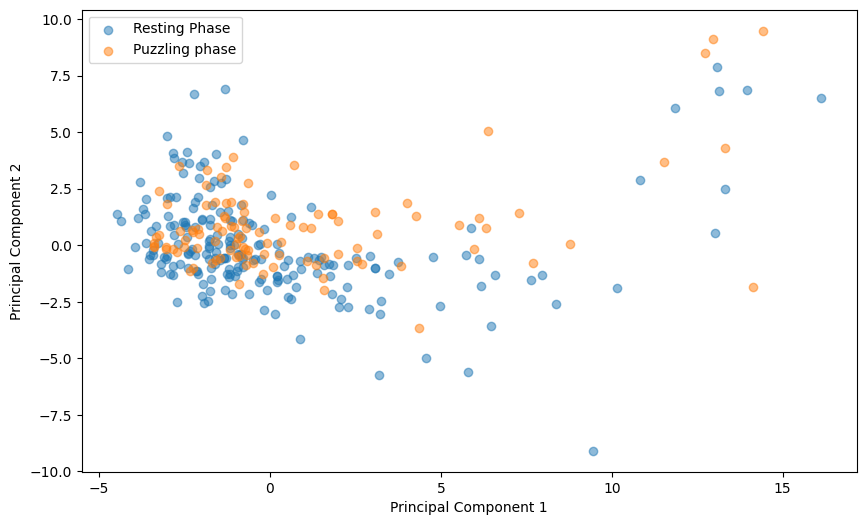

In [ ]:
train_df_pca = pca.transform(train_df_scaled)
test_df_pca = pca.transform(test_df_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(train_df_pca[:, 0], train_df_pca[:, 1], label="Resting Phase", alpha=0.5)
plt.scatter(test_df_pca[:, 0], test_df_pca[:, 1], label="Puzzling phase", alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [ ]:
train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[data_columns] = train_df_scaled[data_columns].astype(float)
test_df_scaled[data_columns] = test_df_scaled[data_columns].astype(float)

for individual in df["Individual"].unique():
    individual_data = train_df_scaled[train_df_scaled["Individual"] == individual][data_columns]
    scaler = StandardScaler()
    scaler.fit(individual_data)
    train_df_scaled.loc[train_df_scaled["Individual"] == individual, data_columns] = scaler.transform(individual_data)
    test_individual_data = test_df_scaled[test_df_scaled["Individual"] == individual][data_columns]
    test_df_scaled.loc[test_df_scaled["Individual"] == individual, data_columns] = scaler.transform(test_individual_data)

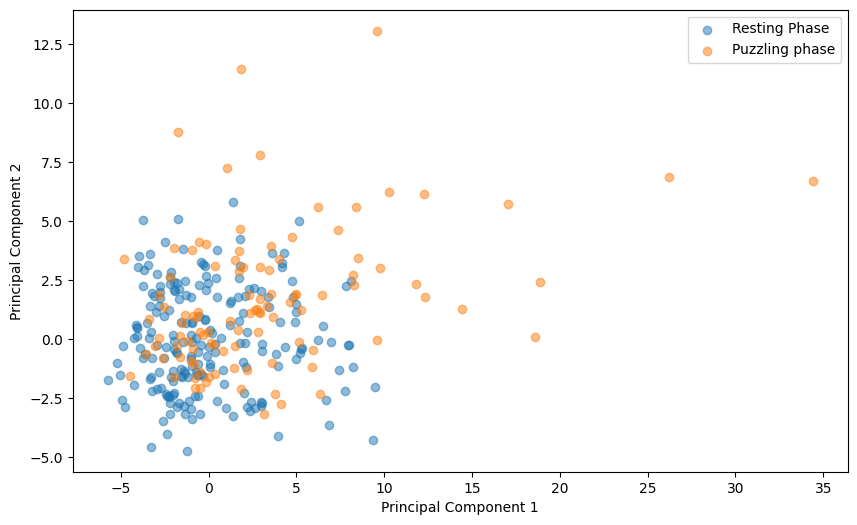

In [ ]:
pca = PCA()
pca.fit(train_df_scaled[data_columns])
explained_variance = pca.explained_variance_ratio_

n_components_95 = (explained_variance.cumsum() <= 0.95).sum()

train_df_pca = pca.transform(train_df_scaled[data_columns])
test_df_pca = pca.transform(test_df_scaled[data_columns])

plt.figure(figsize=(10, 6))
plt.scatter(train_df_pca[:, 0], train_df_pca[:, 1], label="Resting Phase", alpha=0.5)
plt.scatter(test_df_pca[:, 0], test_df_pca[:, 1], label="Puzzling phase", alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()